# Multimodal QSVM — Dementia Detection (Task D)
Fuses clinical + MRI + speech features into one quantum SVM and compares it to a classical SVM baseline.

## Real-data note (2026-09-24, supersedes the synthetic-data note below)
This notebook now trains on the **real** assembled dataset (`data/multimodal_dementia_dataset.csv`,
233 rows — OASIS clinical/MRI cross-matched with windowed speech features by (label, sex, age); see
`real_dataset_setup.md` / `PROJECT_CONTEXT.md` §28-29). Two consequences:

1. **`CDR` is dropped** from the clinical block — OASIS's label is CDR-derived, so keeping it would
   re-inject the label into the clinical features (the exact leak the synthetic-data noise injection
   below was invented to paper over). Feature count is **24** (clinical 4 + MRI 2 + speech 18), not 27.
2. **Cross-validation groups on the composite `speaker_id|oasis_subject_id` unit**
   (`GroupKFold`, not `StratifiedKFold`) — every window from one speaker, and every OASIS subject
   matched to that speaker, must stay on one side of every split, or a repeated voice gets memorised.
3. **`SIGMA_FRAC = 0`** by default — real data does not have the synthetic dataset's trivial
   separability, so noise injection is no longer needed for an honest headline. The machinery is kept
   as an opt-in sensitivity arm (see `metrics_full.ipynb` for the full sensitivity table).

Still true: PCA is fit **inside each CV fold** (train split only) via a `ColumnTransformer`, so this
notebook reads the raw CSV rather than the per-modality `.npy` files, which are fit on the full set.

---

### Original synthetic-data note (superseded, kept for history)
The original `multimodal_dementia_dataset.csv` was synthetic and pre-generated. It was *trivially
separable*: a single feature such as `hippocampal_volume` classified at ~99.6%, and 5-fold CV gave
**100%** for both classical and quantum models — a property of the dataset, not the model. That is
why the notebook added Gaussian noise (`SIGMA_FRAC`) and reported noisy-data CV as the headline. Real
data doesn't have that problem (see the leak probe in `scripts/verify_real_dataset.py` — MMSE/nWBV
stumps land at ~0.79, not ~1.0), so `SIGMA_FRAC` now defaults to 0.


In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC
import warnings
warnings.filterwarnings('ignore')
print('✅ All imports successful')

✅ All imports successful


In [2]:
# Load the raw dataset (not the leaked PCA .npy files) so PCA can be fit inside each fold
df = pd.read_csv('data/multimodal_dementia_dataset.csv')
prov = pd.read_csv('data/multimodal_real_provenance.csv')[['Subject_ID', 'group_id']]
df = df.merge(prov, on='Subject_ID', how='left')
assert df['group_id'].isna().sum() == 0, 'every row must carry a composite speaker|oasis group_id'
y = df['Label'].values
groups = df['group_id'].values

GROUPS = {
    'clinical': ['MMSE', 'ASF', 'EDUC', 'SES'],   # CDR dropped — see the real-data note above
    'mri':      ['nWBV', 'eTIV'],
    'speech':   ['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer']
                + [f'mfcc_{i}' for i in range(1, 14)],
}
ALL_FEATURES = sum(GROUPS.values(), [])
assert len(GROUPS['clinical']) == 4 and len(GROUPS['mri']) == 2 and len(GROUPS['speech']) == 18
assert len(ALL_FEATURES) == 24, len(ALL_FEATURES)

X_raw = df[ALL_FEATURES].values.astype(float)
feature_std = df[ALL_FEATURES].std().values   # per-feature std, used to scale noise (sensitivity arm)
# integer column indices for each modality (for the in-fold ColumnTransformer)
COLS = {g: [ALL_FEATURES.index(c) for c in GROUPS[g]] for g in GROUPS}

print(f'Dataset: {X_raw.shape}  | label distribution: {np.bincount(y)} ([Nondemented, Demented])')
print(f'Feature groups: clinical={len(COLS["clinical"])}, mri={len(COLS["mri"])}, speech={len(COLS["speech"])}')
print(f'Distinct composite groups (speaker|oasis_subject): {len(set(groups))}')


Dataset: (233, 24)  | label distribution: [105 128] ([Nondemented, Demented])
Feature groups: clinical=4, mri=2, speech=18
Distinct composite groups (speaker|oasis_subject): 233


In [3]:
# --- Noise injection: kept as an opt-in sensitivity arm, OFF by default on real data ---
# Noise is scaled by each feature's own std, so SIGMA_FRAC is interpretable as
# 'fraction of a standard deviation' and affects every feature proportionally.
SIGMA_FRAC = 0   # real data: no noise needed for an honest headline (see the note above).
                 # Set > 0 here to reproduce the old synthetic-data sensitivity check.

rng = np.random.default_rng(42)
X_noisy = X_raw + rng.normal(0, SIGMA_FRAC * feature_std, X_raw.shape)

# Sanity check: single-feature stump on the two strongest real features (MMSE, nWBV) —
# these replace the synthetic dataset's 'hippocampal_volume' as the leak-probe target
# (see scripts/verify_real_dataset.py for the full per-feature leak probe).
for feat in ['MMSE', 'nWBV']:
    fi = ALL_FEATURES.index(feat)
    stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_raw[:, [fi]], y).score(X_raw[:, [fi]], y)
    print(f'{feat} single-stump resub accuracy: {stump:.3f}')
print(f'SIGMA_FRAC = {SIGMA_FRAC}')
print('(real, ~0.7-0.85 stumps -- not the ~0.996 the synthetic hippocampal_volume feature gave;')
print(' no noise injection needed to get an honest number on real data.)')


MMSE single-stump resub accuracy: 0.794
nWBV single-stump resub accuracy: 0.794
SIGMA_FRAC = 0
(real, ~0.7-0.85 stumps -- not the ~0.996 the synthetic hippocampal_volume feature gave;
 no noise injection needed to get an honest number on real data.)


In [4]:
# --- Pipeline + leakage-free, group-aware cross-validation ---
# Each fold fits per-modality StandardScaler+PCA(2) on TRAIN only (via ColumnTransformer),
# concatenates to 6 features, MinMax-scales into [0,1] for the quantum angle encoding,
# then fits the classifier. A fresh pipeline is built per fold (no leakage, no clone issues).
# GroupKFold on the composite speaker|oasis_subject group keeps every window from one speaker
# (and every OASIS subject matched to that speaker) on one side of every split.
def make_pipe(kind):
    pre = ColumnTransformer([
        (g, Pipeline([('sc', StandardScaler()), ('pca', PCA(n_components=2))]), COLS[g])
        for g in GROUPS
    ])
    if kind == 'svm':
        clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    else:
        fmap = ZZFeatureMap(feature_dimension=6, reps=2, entanglement='linear')
        clf = QSVC(quantum_kernel=FidelityStatevectorKernel(feature_map=fmap))
    return Pipeline([('modal', pre), ('mm', MinMaxScaler((0, 1))), ('clf', clf)])

def eval_cv(X, kind, seed=42, n_splits=5):
    cv = GroupKFold(n_splits=n_splits)
    accs = []
    for tr, te in cv.split(X, y, groups):
        pipe = make_pipe(kind).fit(X[tr], y[tr])
        accs.append(accuracy_score(y[te], pipe.predict(X[te])))
    return np.array(accs)

print('Pipeline + eval_cv ready (GroupKFold(5) on the composite group).')


Pipeline + eval_cv ready (GroupKFold(5) on the composite group).


In [5]:
# --- Headline: GroupKFold(5) CV on real data, SIGMA_FRAC=0 ---
clean_svm  = eval_cv(X_raw, 'svm')
clean_qsvm = eval_cv(X_raw, 'qsvm')
print('5-fold GroupKFold CV on the real data (leakage-free, group-aware pipeline):')
print(f'  Classical SVM : {clean_svm.mean():.3f} +/- {clean_svm.std():.3f}')
print(f'  QSVM          : {clean_qsvm.mean():.3f} +/- {clean_qsvm.std():.3f}')


5-fold GroupKFold CV on the real data (leakage-free, group-aware pipeline):
  Classical SVM : 0.811 +/- 0.030
  QSVM          : 0.781 +/- 0.078


In [6]:
# --- Sensitivity-arm evaluation on X_noisy (== X_raw when SIGMA_FRAC=0, the default) ---
t0 = time.time()
noisy_svm  = eval_cv(X_noisy, 'svm')
noisy_qsvm = eval_cv(X_noisy, 'qsvm')
print(f'5-fold GroupKFold CV on X_noisy (SIGMA_FRAC={SIGMA_FRAC})   [{time.time()-t0:.1f}s]\n')

print('='*60)
print(f'{"Model":<34}{"CV Accuracy":>20}')
print('-'*60)
print(f'{"Classical SVM (multimodal)":<34}{noisy_svm.mean()*100:>13.2f}% +/- {noisy_svm.std()*100:.2f}')
print(f'{"QSVM ZZFeatureMap (multimodal)":<34}{noisy_qsvm.mean()*100:>13.2f}% +/- {noisy_qsvm.std()*100:.2f}')
print('-'*60)
print(f'{"Akinrotimi QSVM (published base)":<34}{91.25:>13.2f}%')
print(f'{"Chakravarthi Classical (REF-1)":<34}{94.20:>13.2f}%')
print('='*60)
print('\nNote: published baselines use different (real) datasets, so this is a context')
print('comparison, not a like-for-like benchmark. See metrics_full.ipynb for the full')
print('sensitivity table (imputation scheme x tol x windowed-vs-1:1 x R_max x noise x clean/raw audio).')


5-fold GroupKFold CV on X_noisy (SIGMA_FRAC=0)   [6.1s]

Model                                      CV Accuracy
------------------------------------------------------------
Classical SVM (multimodal)                81.14% +/- 3.01
QSVM ZZFeatureMap (multimodal)            78.14% +/- 7.77
------------------------------------------------------------
Akinrotimi QSVM (published base)          91.25%
Chakravarthi Classical (REF-1)            94.20%

Note: published baselines use different (real) datasets, so this is a context
comparison, not a like-for-like benchmark. See metrics_full.ipynb for the full
sensitivity table (imputation scheme x tol x windowed-vs-1:1 x R_max x noise x clean/raw audio).


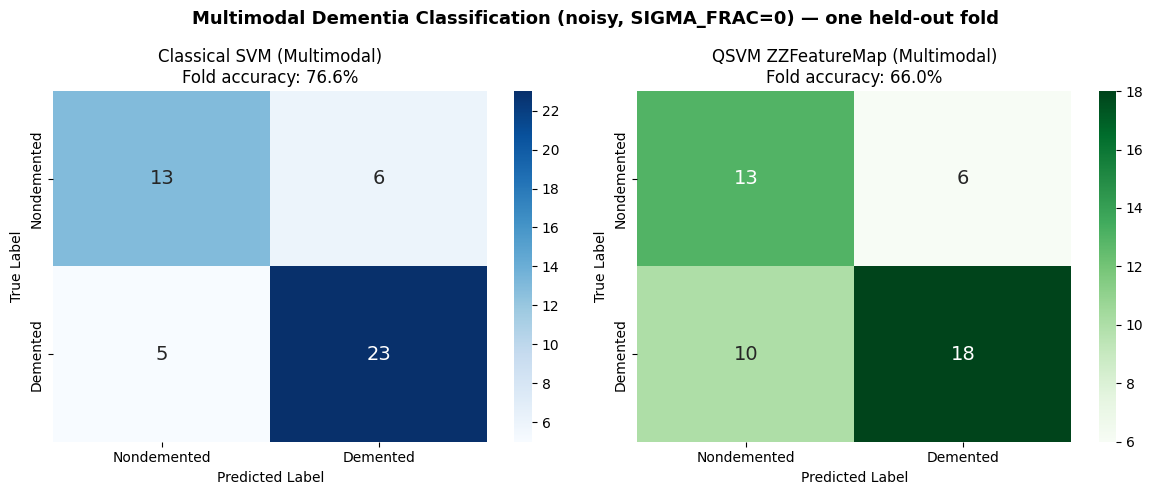

Saved: results/plots/multimodal_confusion_matrix.png


In [7]:
# --- Confusion matrices on one representative held-out fold (noisy data) ---
cv = GroupKFold(n_splits=5)
tr, te = next(iter(cv.split(X_noisy, y, groups)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, kind, title, cmap in zip(
    axes, ['svm', 'qsvm'],
    ['Classical SVM (Multimodal)', 'QSVM ZZFeatureMap (Multimodal)'],
    ['Blues', 'Greens']
):
    pipe = make_pipe(kind).fit(X_noisy[tr], y[tr])
    pred = pipe.predict(X_noisy[te])
    cm = confusion_matrix(y[te], pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmap,
                xticklabels=['Nondemented', 'Demented'],
                yticklabels=['Nondemented', 'Demented'], annot_kws={'size': 14})
    ax.set_title(f'{title}\nFold accuracy: {accuracy_score(y[te], pred)*100:.1f}%', fontsize=12)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')

plt.suptitle(f'Multimodal Dementia Classification (noisy, SIGMA_FRAC={SIGMA_FRAC}) — one held-out fold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/multimodal_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: results/plots/multimodal_confusion_matrix.png')

In [8]:
# --- Persist the full QSVM pipeline + results ---
# Pickle the WHOLE pipeline (per-modality scaler+PCA -> minmax -> QSVC) refit on all real
# data (SIGMA_FRAC=0), so demo-time prediction needs only this one object:
# full_pipe.predict(raw_24_features).
full_pipe = make_pipe('qsvm').fit(X_raw, y)
with open('results/qsvm_model.pkl', 'wb') as f:
    pickle.dump(full_pipe, f)
print('Saved: results/qsvm_model.pkl (full pipeline, real data, no noise)')

with open('results/qsvm_model.pkl', 'rb') as f:
    loaded = pickle.load(f)
assert (loaded.predict(X_raw) == full_pipe.predict(X_raw)).all(), 'Pickle verification failed!'
print('Pickle verified -- reloaded pipeline reproduces predictions')

unmatched_oasis = pd.read_csv('data/unmatched_oasis.csv')
oasis_pool = pd.read_csv('data/oasis_pool.csv')

final_results = {
    'dataset':            'multimodal_dementia_dataset.csv (real: OASIS clinical/MRI x windowed speech, matched by label/sex/age)',
    'n_patients':         int(len(df)),
    'n_features_total':   24,
    'n_features_per_mod': {'clinical': 4, 'mri': 2, 'speech': 18},
    'pca_components':     2,
    'qsvm_feature_dim':   6,
    'cv_folds':           5,
    'cv':                 'GroupKFold(5) composite (speaker_id|oasis_subject_id)',
    'clean_cv': {
        'svm':  {'mean': round(float(clean_svm.mean()), 4),  'std': round(float(clean_svm.std()), 4)},
        'qsvm': {'mean': round(float(clean_qsvm.mean()), 4), 'std': round(float(clean_qsvm.std()), 4)},
    },
    'noisy_cv': {
        'svm':  {'mean': round(float(noisy_svm.mean()), 4),  'std': round(float(noisy_svm.std()), 4)},
        'qsvm': {'mean': round(float(noisy_qsvm.mean()), 4), 'std': round(float(noisy_qsvm.std()), 4)},
        'sigma_frac_used': SIGMA_FRAC,
    },
    'match_counts': {
        'n_distinct_speakers':       int(df['group_id'].str.split('|').str[0].nunique()),
        'n_distinct_oasis_subjects': int(df['group_id'].str.split('|').str[1].nunique()),
        'n_oasis_pool_total':        int(len(oasis_pool)),
        'n_oasis_unmatched':         int(len(unmatched_oasis)),
    },
    'published_baselines': {
        'akinrotimi_qsvm_base':        0.9125,
        'chakravarthi_classical_ref1': 0.9420,
        'so_et_al_clinical_ref7':      0.9720,
        'lin_washington_speech_ref6':  0.8400,
    },
}
with open('results/multimodal_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)
print('\nSaved: results/multimodal_results.json')
print(json.dumps(final_results, indent=2))


Saved: results/qsvm_model.pkl (full pipeline, real data, no noise)


Pickle verified -- reloaded pipeline reproduces predictions

Saved: results/multimodal_results.json
{
  "dataset": "multimodal_dementia_dataset.csv (real: OASIS clinical/MRI x windowed speech, matched by label/sex/age)",
  "n_patients": 233,
  "n_features_total": 24,
  "n_features_per_mod": {
    "clinical": 4,
    "mri": 2,
    "speech": 18
  },
  "pca_components": 2,
  "qsvm_feature_dim": 6,
  "cv_folds": 5,
  "cv": "GroupKFold(5) composite (speaker_id|oasis_subject_id)",
  "clean_cv": {
    "svm": {
      "mean": 0.8114,
      "std": 0.0301
    },
    "qsvm": {
      "mean": 0.7814,
      "std": 0.0777
    }
  },
  "noisy_cv": {
    "svm": {
      "mean": 0.8114,
      "std": 0.0301
    },
    "qsvm": {
      "mean": 0.7814,
      "std": 0.0777
    },
    "sigma_frac_used": 0
  },
  "match_counts": {
    "n_distinct_speakers": 53,
    "n_distinct_oasis_subjects": 233,
    "n_oasis_pool_total": 385,
    "n_oasis_unmatched": 152
  },
  "published_baselines": {
    "akinrotimi_qsvm_bas